# Figure: Seattle weather, 2012 to 2015

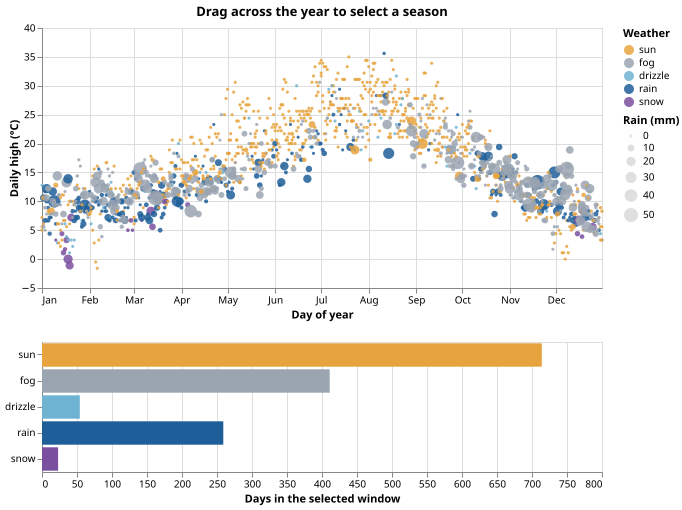

In [1]:
#| label: fig-rain
import csv
import altair as alt, vl_convert as vlc
from IPython.display import display

with open("data/seattle-weather.csv") as f:
    rows = [
        {**r, **{k: float(r[k]) for k in ("precipitation", "temp_max", "temp_min", "wind")}}
        for r in csv.DictReader(f)
    ]

kinds = ["sun", "fog", "drizzle", "rain", "snow"]
palette = ["#e7a33e", "#9aa5b1", "#6fb3d2", "#1f5f99", "#7b4fa0"]
color = alt.Color("weather:N", scale=alt.Scale(domain=kinds, range=palette), title="Weather")

brush = alt.selection_interval(encodings=["x"], name="window")
pick = alt.selection_point(fields=["weather"], bind="legend", name="kind")

days = (
    alt.Chart()
    .mark_circle(size=28)
    .encode(
        x=alt.X("monthdate(date):T", title="Day of year", axis=alt.Axis(format="%b")),
        y=alt.Y("temp_max:Q", title="Daily high (°C)"),
        size=alt.Size("precipitation:Q", title="Rain (mm)", scale=alt.Scale(range=[10, 220])),
        color=alt.condition(brush & pick, color, alt.value("#d9d9d9")),
        opacity=alt.condition(pick, alt.value(0.85), alt.value(0.15)),
        tooltip=[
            alt.Tooltip("date:T", title="Date", format="%d %b %Y"),
            alt.Tooltip("weather:N", title="Weather"),
            alt.Tooltip("precipitation:Q", title="Rain (mm)"),
            alt.Tooltip("temp_max:Q", title="High (°C)"),
            alt.Tooltip("temp_min:Q", title="Low (°C)"),
        ],
    )
    .add_params(brush, pick)
    .properties(width=560, height=260, title="Drag across the year to select a season")
)

counts = (
    alt.Chart()
    .mark_bar()
    .encode(
        x=alt.X("count():Q", title="Days in the selected window"),
        y=alt.Y("weather:N", sort=kinds, title=None),
        color=color,
        tooltip=[alt.Tooltip("weather:N", title="Weather"), alt.Tooltip("count():Q", title="Days")],
    )
    .transform_filter(brush)
    .properties(width=560, height=130)
)

chart = alt.vconcat(days, counts, data=alt.Data(values=rows))

display(
    {
        "text/html": chart._repr_mimebundle_(None, None)["text/html"],  # web: interactive
        "image/svg+xml": vlc.vegalite_to_svg(chart.to_json()),          # PDF: static, vector
    },
    raw=True,
)
